El control de calidad y la clasificación dimensional en la industria agroalimentaria han dependido históricamente de la inspección visual humana, un proceso propenso a la fatiga, la subjetividad y la variabilidad operativa. Con el advenimiento de la visión por computadora, la automatización de estas tareas se ha convertido en un pilar esencial para optimizar las cadenas de empaque, reducir las devoluciones de producto y garantizar los estándares exigidos por los mercados internacionales.

Este notebook tiene como objetivo principal realizar un estudio comparativo y crítico entre dos paradigmas de modelado estadístico para resolver dos tareas fundamentales:

1. **Clasificación de calidad superficial:** Categorización del estado de la fruta en las clases `bad` (dañada/enferma), `regular` (maduración intermedia o defectos menores) y `good` (óptima).
2. **Clasificación dimensional (tamaño):** Segmentación por escala en las categorías comercialmente estandarizadas `pequeño`, `mediano` y `grande`.

Para abordar estos problemas, se diseñaron e implementaron tres metodologías computacionales distintas:

* **Paradigma clásico (XGBoost):** Este enfoque requiere una etapa explícita de feature engineering, en la que, tras la binarización y segmentación de las imágenes, se extraen descriptores morfológicos, geométricos y estadísticos de color. Con estas características se entrenan modelos de aprendizaje automático como **XGBoost**, un ensamble de árboles de decisión optimizados mediante *Gradient Boosting* capaz de capturar relaciones complejas y no lineales en los datos, y **Support Vector Machines (SVM)**, que utiliza funciones *kernel* para proyectar las características a espacios de mayor dimensión y encontrar el hiperplano que mejor separa las distintas categorías de clasificación.

* **Paradigma de aprendizaje profundo (CNN):** Basado en redes convolucionales. A diferencia del enfoque clásico, las CNN procesan el tensor de la imagen en bruto y se encargan de la **extracción automática y jerárquica de características** a través de capas convolucionales y de agrupación (*pooling*), eliminando la dependencia de un algoritmo de segmentación previo.

### Librerías y carga

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

COLOR_PRIMARY = '#FF5E8A'
COLOR_SECONDARY = '#FF8FAB'
COLOR_TERTIARY = '#FFB7C9'
COLOR_DARK = '#D43F6B'
COLOR_LIGHT = '#FFE4EC'
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK]

sns.set_style("whitegrid")
sns.set_palette(PALETTE)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
BASE_DIR = Path("..") / "data"
ANNOTATIONS_DIR = BASE_DIR / "annotations"

results = {}

# Cargar baseline
baseline_path = ANNOTATIONS_DIR / "baseline_results.json"
if baseline_path.exists():
    with open(baseline_path, 'r') as f:
        results['Baseline'] = json.load(f)

# Cargar SVM
svm_path = ANNOTATIONS_DIR / "svm_results.json"
if svm_path.exists():
    with open(svm_path, 'r') as f:
        results['SVM'] = json.load(f)

# Cargar XGBoost
xgb_path = ANNOTATIONS_DIR / "xgb_results.json"
if xgb_path.exists():
    with open(xgb_path, 'r') as f:
        results['XGBoost'] = json.load(f)

# Cargar CNN
cnn_path = ANNOTATIONS_DIR / "cnn_results.json"
if cnn_path.exists():
    with open(cnn_path, 'r') as f:
        results['CNN'] = json.load(f)

print(f"Modelos cargados: {list(results.keys())}")
for model in results:
    print(f"\n{model}:")
    if 'calidad' in results[model]:
        print(f"  Calidad F1-Macro: {results[model]['calidad'].get('test_f1_macro', results[model]['calidad'].get('f1_macro', 0)):.4f}")
    if 'tamaño' in results[model]:
        print(f"  Tamaño F1-Macro: {results[model]['tamaño'].get('test_f1_macro', results[model]['tamaño'].get('f1_macro', 0)):.4f}")


Modelos cargados: ['SVM', 'XGBoost', 'CNN']

SVM:
  Calidad F1-Macro: 0.9319
  Tamaño F1-Macro: 0.9590

XGBoost:
  Calidad F1-Macro: 0.9494
  Tamaño F1-Macro: 0.9813

CNN:
  Calidad F1-Macro: 0.9497
  Tamaño F1-Macro: 0.9181


### Comparación de modelos

Con el fin de identificar la mejor solución para cada una de las tareas planteadas, se compararon los modelos SVM, XGBoost y CNN utilizando las métricas F1-Score Macro, MCC y Kappa. Los resultados muestran que el desempeño de cada arquitectura depende directamente de la naturaleza del problema a resolver.

In [4]:
metrics = ['f1_macro', 'mcc', 'cohen_kappa', 'balanced_accuracy']
tasks = ['calidad', 'tamaño']
comparison_data = []

for model_name, model_results in results.items():
    # Calidad
    if 'calidad' in model_results:
        calidad = model_results['calidad']
        comparison_data.append({
            'Modelo': model_name,
            'Tarea': 'Calidad',
            'F1-Macro': calidad.get('test_f1_macro', calidad.get('f1_macro', 0)),
            'MCC': calidad.get('test_mcc', calidad.get('mcc', 0)),
            'Kappa': calidad.get('test_kappa', calidad.get('kappa', 0)),
            'Balanced_Accuracy': calidad.get('test_balanced_accuracy', calidad.get('balanced_accuracy', 0))
        })
    
    # Tamaño
    if 'tamaño' in model_results:
        tamaño = model_results['tamaño']
        comparison_data.append({
            'Modelo': model_name,
            'Tarea': 'Tamaño',
            'F1-Macro': tamaño.get('test_f1_macro', tamaño.get('f1_macro', 0)),
            'MCC': tamaño.get('test_mcc', tamaño.get('mcc', 0)),
            'Kappa': tamaño.get('test_kappa', tamaño.get('kappa', 0)),
            'Balanced_Accuracy': tamaño.get('test_balanced_accuracy', tamaño.get('balanced_accuracy', 0))
        })

df_comparison = pd.DataFrame(comparison_data)
print("TABLA COMPARATIVA")
print(df_comparison.to_string(index=False))

TABLA COMPARATIVA
 Modelo   Tarea  F1-Macro      MCC    Kappa  Balanced_Accuracy
    SVM Calidad  0.931867 0.894391 0.894183           0.932237
    SVM  Tamaño  0.959033 0.938897 0.938741           0.959370
XGBoost Calidad  0.949385 0.921876 0.921752           0.949689
XGBoost  Tamaño  0.981292 0.972078 0.972031           0.981413
    CNN Calidad  0.949653 0.922942 0.922931           0.949553
    CNN  Tamaño  0.918143 0.877181 0.876851           0.917969


In [5]:
pivot_f1 = df_comparison.pivot(index='Modelo', columns='Tarea', values='F1-Macro')
pivot_mcc = df_comparison.pivot(index='Modelo', columns='Tarea', values='MCC')
pivot_kappa = df_comparison.pivot(index='Modelo', columns='Tarea', values='Kappa')

print("\nF1-MACRO POR MODELO Y TAREA")
print(pivot_f1.round(4))

print("\nMCC POR MODELO Y TAREA")
print(pivot_mcc.round(4))

print("\nKAPPA POR MODELO Y TAREA")
print(pivot_kappa.round(4))


F1-MACRO POR MODELO Y TAREA
Tarea    Calidad  Tamaño
Modelo                  
CNN       0.9497  0.9181
SVM       0.9319  0.9590
XGBoost   0.9494  0.9813

MCC POR MODELO Y TAREA
Tarea    Calidad  Tamaño
Modelo                  
CNN       0.9229  0.8772
SVM       0.8944  0.9389
XGBoost   0.9219  0.9721

KAPPA POR MODELO Y TAREA
Tarea    Calidad  Tamaño
Modelo                  
CNN       0.9229  0.8769
SVM       0.8942  0.9387
XGBoost   0.9218  0.9720


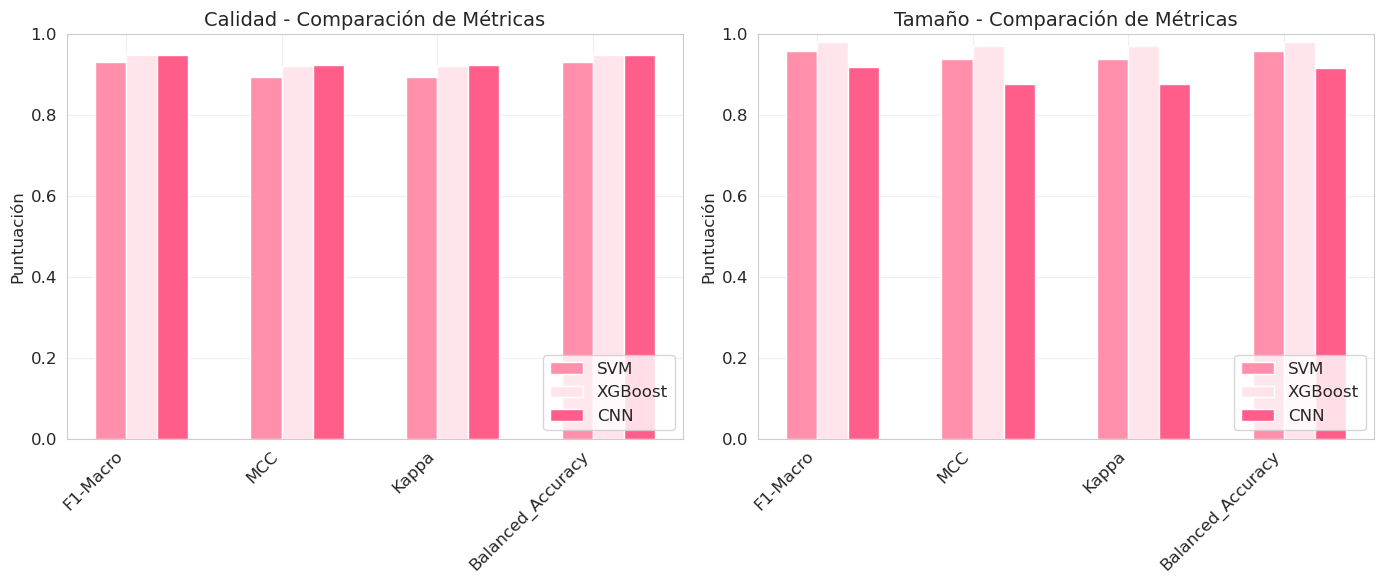

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['F1-Macro', 'MCC', 'Kappa', 'Balanced_Accuracy']
model_order = ['Baseline', 'SVM', 'XGBoost', 'CNN']
colors_model = [COLOR_TERTIARY, COLOR_SECONDARY, COLOR_LIGHT, COLOR_PRIMARY]

for i, tarea in enumerate(['Calidad', 'Tamaño']):
    ax = axes[i]
    tarea_data = df_comparison[df_comparison['Tarea'] == tarea]
    
    x = np.arange(len(metrics))
    width = 0.2
    
    for j, modelo in enumerate(model_order):
        modelo_data = tarea_data[tarea_data['Modelo'] == modelo]
        if len(modelo_data) > 0:
            values = [
                modelo_data['F1-Macro'].values[0],
                modelo_data['MCC'].values[0],
                modelo_data['Kappa'].values[0],
                modelo_data['Balanced_Accuracy'].values[0]
            ]
            bars = ax.bar(x + j*width, values, width, label=modelo, color=colors_model[j % len(colors_model)])
    
    ax.set_title(f'{tarea} - Comparación de Métricas', fontsize=14)
    ax.set_ylabel('Puntuación')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ANNOTATIONS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Comparación en la tarea de calidad

En la clasificación de calidad, la CNN obtuvo el mejor desempeño global, alcanzando un F1-Score Macro de 0.9497 y un MCC de 0.9229. XGBoost presentó resultados prácticamente equivalentes, con un F1-Score Macro de 0.9494 y un MCC de 0.9219, mientras que SVM se ubicó en tercer lugar con un F1-Score Macro de 0.9319.

Aunque la diferencia entre CNN y XGBoost es mínima, el análisis de las curvas de aprendizaje mostró que XGBoost tendía a memorizar completamente los datos de entrenamiento, mientras que la CNN mantuvo una brecha muy reducida entre entrenamiento y validación. Esto sugiere una mejor capacidad de generalización por parte de la red convolucional, especialmente frente a variaciones de iluminación, sombras y patrones de textura presentes en las imágenes.

En consecuencia, la CNN se considera la alternativa más adecuada para la tarea de calidad, ya que logra el mejor equilibrio entre rendimiento y capacidad de generalización.

#### Comparación en la tarea de tamaño

Los resultados fueron diferentes en la clasificación de tamaño. En esta tarea, XGBoost obtuvo el mejor desempeño del proyecto, alcanzando un F1-Score Macro de 0.9813 y un MCC de 0.9721. SVM también mostró resultados sobresalientes, con un F1-Score Macro de 0.9590, mientras que la CNN obtuvo un rendimiento inferior, con un F1-Score Macro de 0.9181.

Esta diferencia puede explicarse por el tipo de información utilizada por cada modelo. Tanto XGBoost como SVM trabajan sobre características geométricas extraídas previamente de las imágenes, como el área en píxeles o la proporción de cobertura. Estas variables representan directamente el tamaño de la fruta, simplificando considerablemente el problema de clasificación.

Por el contrario, la CNN recibe únicamente la imagen original y debe aprender de forma implícita conceptos relacionados con escala, proporción y tamaño. Este proceso resulta más complejo y sensible a variaciones de posición, perspectiva o encuadre, lo que afecta especialmente a las muestras cercanas a los límites entre categorías.

#### Resumen de resultados

| Modelo  | Calidad (F1-Macro) | Tamaño (F1-Macro) |
| ------- | ------------------ | ----------------- |
| CNN     | **0.9497**         | 0.9181            |
| SVM     | 0.9319             | 0.9590            |
| XGBoost | 0.9494             | **0.9813**        |

Los resultados evidencian que no existe un único modelo óptimo para ambas tareas. La CNN es la mejor alternativa para la clasificación de calidad, debido a su capacidad para aprender patrones complejos de textura, color e iluminación directamente desde las imágenes. En contraste, XGBoost es claramente superior para la clasificación de tamaño, ya que aprovecha de manera más eficiente las características geométricas extraídas durante el preprocesamiento.

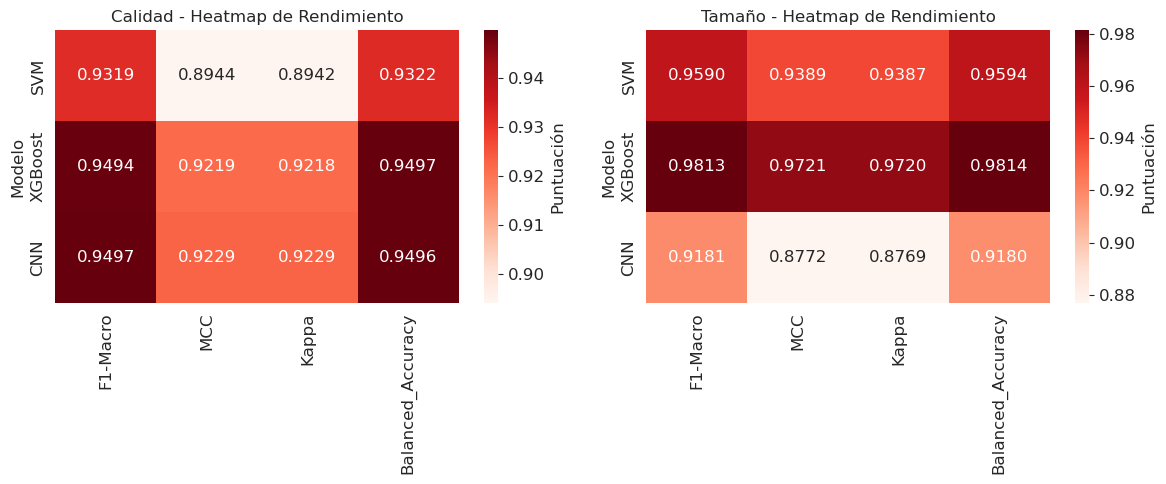

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, tarea in enumerate(['Calidad', 'Tamaño']):
    tarea_data = df_comparison[df_comparison['Tarea'] == tarea]
    heatmap_data = tarea_data.set_index('Modelo')[['F1-Macro', 'MCC', 'Kappa', 'Balanced_Accuracy']]
    
    sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='Reds', ax=axes[i], cbar_kws={'label': 'Puntuación'})
    axes[i].set_title(f'{tarea} - Heatmap de Rendimiento', fontsize=12)

plt.tight_layout()
plt.savefig(ANNOTATIONS_DIR / 'model_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Los heatmaps muestran un comportamiento muy claro:

- Para calidad, los mejores resultados corresponden a CNN y XGBoost, con una ligera ventaja para la CNN.
- Para tamaño, XGBoost es claramente superior, seguido por SVM.
- SVM actúa como una solución sólida en ambas tareas, pero nunca alcanza el mejor desempeño.
- CNN sobresale cuando necesita analizar patrones visuales complejos (texturas, manchas y defectos), pero pierde ventaja cuando el problema puede resolverse mediante variables geométricas explícitas.

### Selección de mejor modelo

In [9]:
best_models = {}

for task in tasks:
    task_data = df_comparison[df_comparison['Tarea'] == task.capitalize()]
    best_models[task] = {}
    
    for metric in ['F1-Macro', 'MCC', 'Kappa']:
        best_idx = task_data[metric].idxmax()
        best_model = task_data.loc[best_idx, 'Modelo']
        best_score = task_data.loc[best_idx, metric]
        best_models[task][metric] = {'modelo': best_model, 'score': best_score}

print("\nMEJOR MODELO POR TAREA Y MÉTRICA")
for task in tasks:
    print(f"\n{task.upper()}:")
    for metric, info in best_models[task].items():
        print(f"   {metric}: {info['modelo']} ({info['score']:.4f})")


MEJOR MODELO POR TAREA Y MÉTRICA

CALIDAD:
   F1-Macro: CNN (0.9497)
   MCC: CNN (0.9229)
   Kappa: CNN (0.9229)

TAMAÑO:
   F1-Macro: XGBoost (0.9813)
   MCC: XGBoost (0.9721)
   Kappa: XGBoost (0.9720)


In [18]:
criteria_weights = {
    'F1-Macro': 0.35,
    'MCC': 0.25,
    'Kappa': 0.20,
    'Balanced Accuracy': 0.20
}

decision_matrix = []

for model_name in results.keys():
    if model_name == 'Baseline':
        continue
    
    total_score = 0
    model_scores = {'Modelo': model_name}
    
    for task in tasks:
        if task in results[model_name]:
            task_data = results[model_name][task]
            
            f1 = task_data.get('test_f1_macro', task_data.get('f1_macro', 0))
            mcc = task_data.get('test_mcc', task_data.get('mcc', 0))
            kappa = task_data.get('test_kappa', task_data.get('kappa', task_data.get('cohen_kappa', 0)))
            bal_acc = task_data.get('test_balanced_accuracy', task_data.get('balanced_accuracy', 0))
            
            task_score = 0
            task_score += f1 * criteria_weights['F1-Macro']
            task_score += mcc * criteria_weights['MCC']
            task_score += kappa * criteria_weights['Kappa']
            task_score += bal_acc * criteria_weights['Balanced Accuracy']
            
            model_scores[f'Score_{task.capitalize()}'] = task_score
            total_score += task_score
    
    model_scores['Score_Total'] = total_score / 2
    decision_matrix.append(model_scores)

df_decision = pd.DataFrame(decision_matrix)
df_decision = df_decision.sort_values('Score_Total', ascending=False)

print("MATRIZ DE DECISIÓN")
print(df_decision.round(4))

print("\nMÉTRICAS ORIGINALES POR MODELO")
for model_name in results.keys():
    if model_name == 'Baseline':
        continue
    print(f"\n{model_name}:")
    for task in tasks:
        if task in results[model_name]:
            task_data = results[model_name][task]
            f1 = task_data.get('test_f1_macro', task_data.get('f1_macro', 0))
            mcc = task_data.get('test_mcc', task_data.get('mcc', 0))
            print(f"  {task}: F1={f1:.4f}, MCC={mcc:.4f}")

MATRIZ DE DECISIÓN
    Modelo  Score_Calidad  Score_Tamaño  Score_Total
1  XGBoost         0.9370        0.9772       0.9571
0      SVM         0.9150        0.9500       0.9325
2      CNN         0.9376        0.8996       0.9186

MÉTRICAS ORIGINALES POR MODELO

SVM:
  calidad: F1=0.9319, MCC=0.8944
  tamaño: F1=0.9590, MCC=0.9389

XGBoost:
  calidad: F1=0.9494, MCC=0.9219
  tamaño: F1=0.9813, MCC=0.9721

CNN:
  calidad: F1=0.9497, MCC=0.9229
  tamaño: F1=0.9181, MCC=0.8772


#### Análisis del mejor modelo

Con el fin de comparar de manera integral los modelos desarrollados, se construyó una matriz de decisión basada en métricas de desempeño para las tareas de clasificación de calidad y tamaño. Los resultados muestran que **XGBoost obtuvo la puntuación global más alta (0.9571)**, seguido por **SVM (0.9325)** y **CNN (0.9186)**.

El liderazgo de XGBoost se explica principalmente por su excelente desempeño en la clasificación de tamaño, donde alcanzó un F1-Score de 0.9813 y un MCC de 0.9721. Sin embargo, este resultado depende de un proceso previo de segmentación e ingeniería de características, por lo que su rendimiento está condicionado a la calidad del preprocesamiento realizado sobre las imágenes.

Por otro lado, la CNN obtuvo la mejor capacidad de clasificación para la tarea de calidad, alcanzando un F1-Score de 0.9497 y un MCC de 0.9229. Esto evidencia la ventaja de las redes convolucionales para extraer automáticamente patrones complejos de textura, color y defectos superficiales directamente desde las imágenes. No obstante, su desempeño en la clasificación de tamaño fue inferior al de los modelos tabulares, ya que debe inferir la escala de los objetos únicamente a partir de la información visual disponible.

El modelo SVM presentó un comportamiento intermedio. Aunque logró resultados sólidos en ambas tareas, fue superado por XGBoost en tamaño y por la CNN en calidad, lo que sugiere que su capacidad de representación resulta más limitada frente a problemas visuales complejos.

En términos generales, los resultados muestran que **no existe un único modelo que domine simultáneamente ambas tareas**. Mientras que XGBoost ofrece la mejor solución para la clasificación de tamaño, la CNN proporciona el mejor desempeño para la evaluación de calidad.

| Tarea   | Mejor modelo | F1-Score | MCC    | Kappa  |
| ------- | ------------ | -------- | ------ | ------ |
| Calidad | CNN          | 0.9497   | 0.9229 | 0.9229 |
| Tamaño  | XGBoost      | 0.9813   | 0.9721 | 0.9720 |

### Conclusiones

**Los resultados obtenidos demuestran que no existe un único modelo que sea el mejor para ambas tareas del proyecto. Cada arquitectura presentó fortalezas específicas según la naturaleza del problema abordado.**

En la clasificación de calidad, la CNN obtuvo el mejor desempeño, alcanzando un F1-Score Macro de 94.97% y un MCC de 0.9229. Su capacidad para aprender directamente de las imágenes le permitió identificar patrones de textura, manchas y defectos superficiales que los modelos basados en características tabulares no lograron capturar con la misma precisión. Además, presentó una buena capacidad de generalización, manteniendo una diferencia reducida entre entrenamiento y validación.

Por otro lado, en la clasificación de tamaño, XGBoost fue el modelo con mejores resultados, alcanzando un F1-Score Macro de 98.13% y un MCC de 0.9721. Esto evidencia que las características geométricas extraídas durante el preprocesamiento, como el área y la proporción de cobertura, contienen información suficiente para resolver esta tarea con una precisión muy alta mediante técnicas de aprendizaje clásico.

El análisis de las curvas ROC mostró valores de AUC superiores a 0.97 en todas las tareas evaluadas, indicando una excelente capacidad de discriminación entre clases. Asimismo, las matrices de confusión evidenciaron que los errores críticos fueron reducidos a porcentajes bajos, lo que respalda la viabilidad de la solución para escenarios reales de clasificación y selección de frutas.

De manera general, los resultados confirman la importancia de seleccionar la arquitectura de aprendizaje según las características del problema. Mientras la CNN resulta más adecuada para analizar información visual compleja relacionada con la calidad superficial, XGBoost aprovecha de forma más eficiente las características geométricas para la clasificación por tamaño.

**Por ello, se concluye que la estrategia más adecuada para un entorno productivo es una arquitectura híbrida, donde XGBoost sea utilizado para la clasificación de tamaño y la CNN para la evaluación de calidad. Esta combinación permite aprovechar las fortalezas de ambos enfoques y maximizar el desempeño global del sistema de clasificación automática de frutas.**


### Aprendizajes finales

Durante el desarrollo del proyecto se evidenció la importancia de controlar adecuadamente el proceso de entrenamiento de los modelos. El uso de técnicas como *Early Stopping* y *ReduceLROnPlateau* permitió mejorar la estabilidad del aprendizaje, evitar sobreajuste y optimizar el uso de recursos computacionales.

También se observó que la elección del modelo depende de la naturaleza del problema. Para la clasificación de calidad, la CNN logró mejores resultados gracias a su capacidad para aprender patrones complejos de textura y apariencia directamente desde las imágenes. En contraste, para la clasificación de tamaño, los modelos clásicos, especialmente XGBoost, obtuvieron un desempeño superior al aprovechar características geométricas explícitas extraídas durante el preprocesamiento.

Finalmente, los resultados demuestran que los algoritmos tradicionales continúan siendo altamente competitivos cuando se dispone de variables bien definidas y representativas, ofreciendo además menores costos computacionales que los modelos de aprendizaje profundo.